## 333 - How to Detect Highs and Lows

[Youtube](https://www.youtube.com/watch?v=vS-NiGQcrLE)

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from datetime import datetime, timezone
from siphon.catalog import TDSCatalog
from metpy.calc import find_peaks
from metpy.plots import scattertext
from metpy.units import units

In [2]:
# https://www.ncei.noaa.gov/thredds

In [3]:
catalog_url = 'https://www.ncei.noaa.gov/thredds/catalog/model-gfs-g4-anl-files-old/201305/20130520/catalog.xml'

In [4]:
cat = TDSCatalog(catalog_url)

In [5]:
cat.datasets

['gfsanl_4_20130520_1800_006.grb2', 'gfsanl_4_20130520_1800_003.grb2', 'gfsanl_4_20130520_1800_000.grb2', 'gfsanl_4_20130520_1200_006.grb2', 'gfsanl_4_20130520_1200_003.grb2', 'gfsanl_4_20130520_1200_000.grb2', 'gfsanl_4_20130520_0600_006.grb2', 'gfsanl_4_20130520_0600_003.grb2', 'gfsanl_4_20130520_0600_000.grb2', 'gfsanl_4_20130520_0000_006.grb2', 'gfsanl_4_20130520_0000_003.grb2', 'gfsanl_4_20130520_0000_000.grb2']

In [6]:
ds = cat.datasets['gfsanl_4_20130520_1800_003.grb2']

In [7]:
ncss = ds.subset()

In [8]:
query = ncss.query()
query.lonlat_box(west=-125, east=-66.5, south=24, north=50)
query.accept('netcdf')
query.variables('Pressure_reduced_to_MSL_msl')
query.add_lonlat(True)

var=Pressure_reduced_to_MSL_msl&west=-125&east=-66.5&south=24&north=50&accept=netcdf&addLatLon=True

In [9]:
data = ncss.get_data(query)

In [10]:
data

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    Originating_or_generating_Center: US National Weather Service, National Centres for Environmental Prediction (NCEP)
    Originating_or_generating_Subcenter: 0
    GRIB_table_version: 2,1
    Type_of_generating_process: Forecast
    Analysis_or_forecast_generating_process_identifier_defined_by_originating_centre: Global Forecast System Model T1534 - Forecast hours 00-384 T574 - Forecast hours 00-192 T190 - Forecast hours 204-384
    Conventions: CF-1.6
    history: Read using CDM IOSP GribCollection v3
    featureType: GRID
    History: Translated to CF-1.0 Conventions by Netcdf-Java CDM (CFGridCoverageWriter)
Original Dataset = gfsanl_4_20130520_1800_003.grb2#SRC; Translation Date = 2026-06-30T14:50:18.047Z
    geospatial_lat_min: 23.75
    geospatial_lat_max: 50.25
    geospatial_lon_min: -125.25
    geospatial_lon_max: -66.25
    dimensions(sizes): latitude(53), time(1), longitude(118)
    var

In [11]:
lats = data.variables['latitude'][:]
lons = data.variables['longitude'][:]
mslp = np.squeeze(data.variables['Pressure_reduced_to_MSL_msl'][:]) * units(data.variables['Pressure_reduced_to_MSL_msl'].units)

In [12]:
np.shape(mslp)

(53, 118)

In [13]:
mslp = xr.DataArray(mslp / 100, coords={'latitude':lats, 'longitude':lons}, dims=('latitude', 'longitude'), name='mslp')

In [14]:
mslp

<xarray.DataArray 'mslp' (latitude: 53, longitude: 118)> Size: 50kB
array([[1020.25796875, 1019.75296875, 1019.20898438, ..., 1015.23      ,
        1015.62703125, 1016.04      ],
       [1020.71101562, 1020.26      , 1019.76898437, ..., 1015.64898438,
        1016.06796875, 1016.48703125],
       [1021.20796875, 1020.805     , 1020.35898437, ..., 1015.96898437,
        1016.38898437, 1016.79796875],
       ...,
       [1018.53203125, 1018.25      , 1018.005     , ..., 1018.96703125,
        1019.03796875, 1019.12796875],
       [1018.43101562, 1018.16      , 1017.92203125, ..., 1018.59601562,
        1018.67      , 1018.76398437],
       [1018.32      , 1018.055     , 1017.82      , ..., 1018.19      ,
        1018.27601563, 1018.38101563]], shape=(53, 118))
Coordinates:
  * latitude   (latitude) float32 212B 50.0 49.5 49.0 48.5 ... 25.0 24.5 24.0
  * longitude  (longitude) float32 472B 235.0 235.5 236.0 ... 292.5 293.0 293.5

In [19]:
h_y, h_x = find_peaks(mslp.values)
l_y, l_x = find_peaks(mslp.values, maxima=False)

print('Highs: ', h_x,h_y)
print('Lows: ', l_x,l_y)

Highs:  [117, 0, 87] [32, 7, 0]
Lows:  [55] [9]


TextCollection

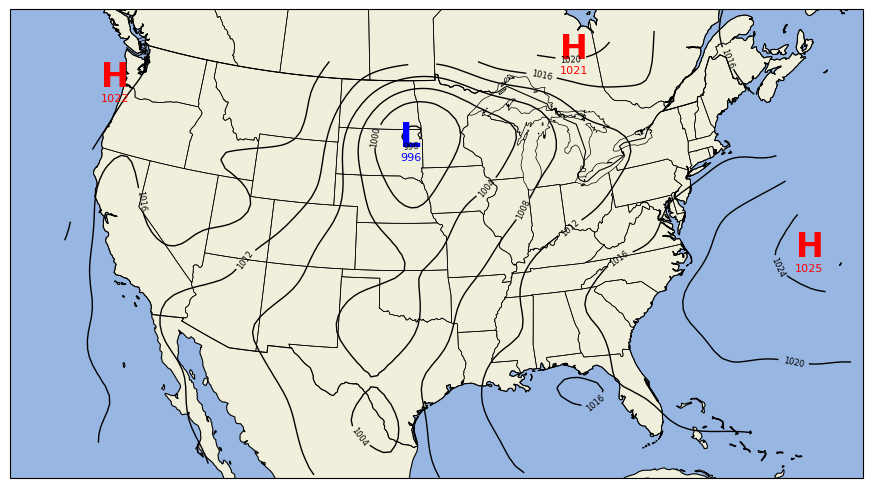

In [26]:
fig = plt.figure(figsize=(11,8))
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-98, central_latitude=35))

ax.set_extent([-125, -66.6, 24, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.8)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)

cs = ax.contour(mslp.longitude, mslp.latitude, mslp, colors='k', transform=ccrs.PlateCarree(), linewidths=1)
ax.clabel(cs, fmt='%d', fontsize=6)

scattertext(ax, mslp['longitude'][h_x], mslp['latitude'][h_y], "H", color='red', size=24, fontweight='bold', transform=ccrs.PlateCarree())
scattertext(ax, mslp['longitude'][l_x], mslp['latitude'][l_y], "L", color='blue', size=24, fontweight='bold', transform=ccrs.PlateCarree())

scattertext(ax, mslp['longitude'][h_x], mslp['latitude'][h_y], mslp.values[h_y, h_x], color='red', size=8, loc=(0, -15), transform=ccrs.PlateCarree(), formatter='.0f')
scattertext(ax, mslp['longitude'][l_x], mslp['latitude'][l_y], mslp.values[l_y, l_x], color='blue', size=8, loc=(0, -15), transform=ccrs.PlateCarree(), formatter='.0f')
